In [3]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.datasets import make_blobs, make_classification, make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.spatial.distance import cosine
import pandas as pd
import time

In [4]:
df = pd.read_csv('Iris.csv')
df.head(5)
df['Species'].unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

In [5]:
df.info()
miss = df.isna().any(axis=1).sum()
print(miss)

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB
0


In [45]:
df.describe()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [46]:
print("\nРаспределение классов:")
class_dist = df['Species'].value_counts()
print(class_dist)


Распределение классов:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [56]:

X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df['Species']

print(X.head())

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=101)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(pd.DataFrame(X_train_scaled, columns=X.columns).head())



   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0       0.764161     -0.177061       1.118100      1.247737
1      -0.426739     -1.398171       0.109288      0.098925
2       0.764161     -0.177061       0.949965      0.737154
3      -0.069469     -0.909727       0.053243     -0.028720
4       1.121431     -0.177061       0.949965      1.120092


In [57]:
knn = KNeighborsClassifier()#n_neighbors=5, weights='distance', metric='euclidean')
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")


Accuracy: 0.9666666666666667


In [58]:

results = []

# Параметры для теста
k_values = [1, 3, 5, 7, 9]
metrics = ['euclidean', 'manhattan', 'minkowski']
weights_options = ['uniform', 'distance']
for k in k_values:
    for metric in metrics:
        for weights in weights_options:
            # Реализация sklearn
            start_time = time.time()
            sklearn_metric = 'minkowski' if metric == 'euclidean' else metric
            sklearn_p = 2 if metric == 'euclidean' else (3 if metric == 'minkowski' else 1)
            sklearn_knn = KNeighborsClassifier(n_neighbors=k, metric=sklearn_metric, weights=weights, p=sklearn_p)
            sklearn_knn.fit(X_train, y_train)
            sklearn_accuracy = sklearn_knn.score(X_test, y_test)
            sklearn_time = time.time() - start_time

            # Добавляем результаты в таблицу
            results.append({
                'k': k,
                'metric': metric,
                'weights': weights,
                'sklearn_accuracy': sklearn_accuracy,
                'sklearn_time': sklearn_time
            })

# Создаем DataFrame для удобного отображения результатов
results_df = pd.DataFrame(results)
print("Сравнение точности и времени выполнения:")
print(results_df)

Сравнение точности и времени выполнения:
    k     metric   weights  sklearn_accuracy  sklearn_time
0   1  euclidean   uniform          1.000000      0.004127
1   1  euclidean  distance          1.000000      0.003252
2   1  manhattan   uniform          0.933333      0.004233
3   1  manhattan  distance          0.933333      0.003325
4   1  minkowski   uniform          1.000000      0.003667
5   1  minkowski  distance          1.000000      0.004081
6   3  euclidean   uniform          1.000000      0.004373
7   3  euclidean  distance          1.000000      0.002929
8   3  manhattan   uniform          1.000000      0.003169
9   3  manhattan  distance          1.000000      0.002722
10  3  minkowski   uniform          1.000000      0.003201
11  3  minkowski  distance          1.000000      0.002766
12  5  euclidean   uniform          1.000000      0.003020
13  5  euclidean  distance          1.000000      0.002644
14  5  manhattan   uniform          0.966667      0.003164
15  5  manhatta

Масштабирование помогает сделать анализ и итоговые вычисления более точными и приемлимыми для восприятия, потому что некоторые признаки имеют большой разброс, а другие маленький, то есть признак с большим значением будет иметь "больший вес". ДЛя knn это важно потому, что алгоритм построен на расстоянии между точками,и нам нужны пропорциональные величины, чтобы какой-то один "не перетягивал одеяло на себя"

Параметры для тестовой выборки нельзя подбирать, потому что такие данные могут неправильно обучать модель, приводить к завышенным показателям точности, хотя на деле таковыми не являются, то есть модель будет знать правильные ответы, но при встрече с новыми данными не сможет правильно их классифицировать



In [59]:

from sklearn.model_selection import GridSearchCV
#определяем словарь для перебора
sl = {
    'n_neighbors': [1, 3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn2 = KNeighborsClassifier()
cross_valid = GridSearchCV(
    knn2, #оптимизируем модель
    sl, #словарь с данными для перебора
    #cv = 25, #базовое количество частей
    scoring='accuracy', #прицел на точность классификации
    n_jobs=-1 # используем все ядра
)

cross_valid.fit(X_train, y_train) 

print(f"Лучшие параметры: {cross_valid.best_params_}")
print(f"Лучшая точность на CV: {cross_valid.best_score_:.4f}")
print(f"Точность на тесте: {cross_valid.score(X_test, y_test):.4f}")


Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Лучшая точность на CV: 0.9500
Точность на тесте: 1.0000


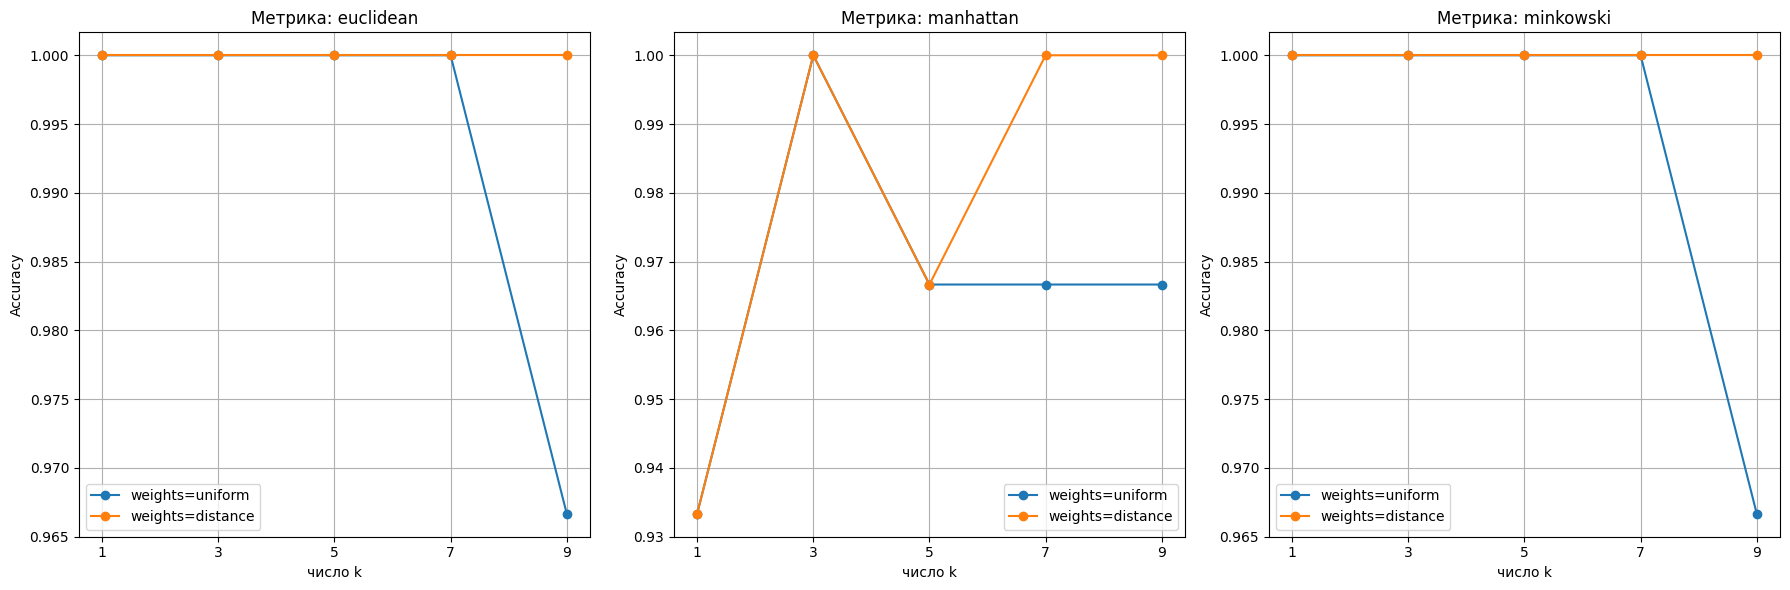

In [60]:

# Зависимость точности от k
plt.figure(figsize=(18, 6))


for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i+1)
    for weights in weights_options:
        subset = results_df[(results_df['metric'] == metric) & (results_df['weights'] == weights)]
        plt.plot(subset['k'], subset['sklearn_accuracy'], marker='o', label=f'weights={weights}')
    plt.title(f'Метрика: {metric}')
    plt.xlabel('число k')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()
    plt.xticks(k_values)

plt.tight_layout()
plt.show()
